In [1]:
# Boilerplate for JupyterLite 
import install_keycap_designer
from keycap_designer.jupyter import *

Layout('ansi-104')
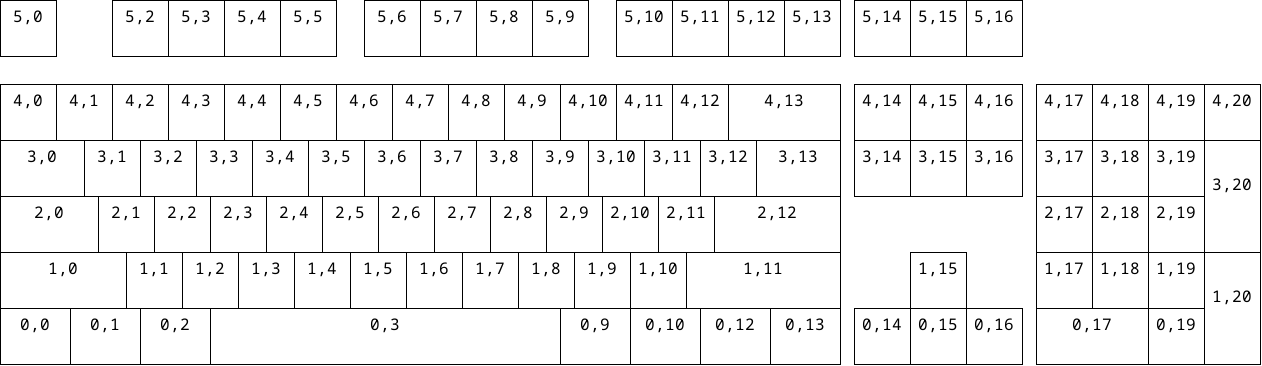

In [2]:
# keycap-designer is designded for making keycap set.
# Let's see how it works.
# We need layout data first. The 'ansi-104' below is a KLE JSON file in the 'layout' folder.
layout = Layout('ansi-104')
layout
# The digits in the rectanbles are "row, col" of each key.


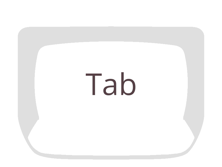
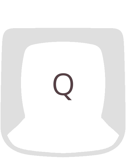
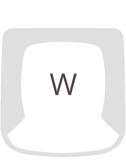

In [3]:
# Boilerplate for legends:
s_center = Style(
    size=4.,
    x_loc=0.,
    y_loc=0.,
    font='OpenSans-VariableFont_wdth,wght.ttf',
    h_o=Center,
    align=Center,
    v_o=Center,
    color= sRGBColor('#000000'),
    side=TopSide
)
m_tab = Junana @ Specifier('15u') @ Legend({s_center: 'Tab'})
m_q = Junana @ Specifier('1u') @ Legend({s_center: 'Q'})
m_w = Junana @ Specifier('1u') @ Legend({s_center: 'W'})

# BTW you can show multiple manuscripts in a line with `show_inline()`:
show_inline([m_tab, m_q, m_w])

In [4]:
# `m_tab` and `m_q` has no information about layout or row-col.
# So the PDF has no information about them:
generate_pdf([m_tab, m_q, m_w], 'step6_non_rc.pdf')

PDF is generated. See: step6_non_rc.pdf


PDF is generated. See: step6_with_rc.pdf



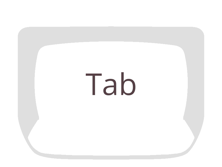
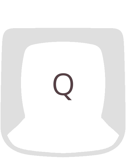
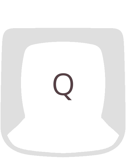

In [5]:
# You can give row-col and layout to manuscripts:
m_tab_rc = m_tab @ Row(3) @ Col(0) @ layout
m_q_rc = m_q @ Row(3) @ Col(1) @ layout
m_w_rc = m_q @ Row(3) @ Col(2) @ layout
generate_pdf([m_tab_rc, m_q_rc, m_w_rc], 'step6_with_rc.pdf')
show_inline([m_tab_rc, m_q_rc, m_w_rc])


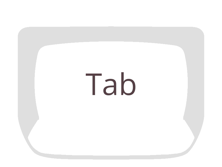
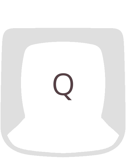
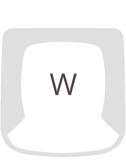

In [6]:
# Should we write `@ Row(...) @ Col(...) @ layout` for each manuscript?
# No, operators `>>` and `**` help you.
ms = layout @ Row(3) >> (Col(0) ** [m_tab, m_q, m_w])
show_inline(ms)
# Look at 'col'. The operator `**` numbers manuscripts incrementally.
# The operator `>>` simply gives information to manuscripts.


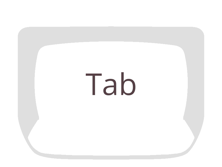
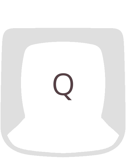
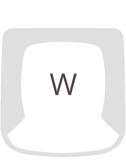
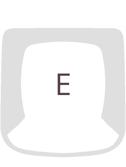
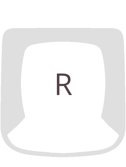
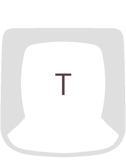
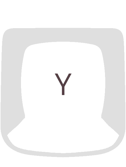

In [7]:
# With those operators and Python features, things can be concise.
ms2 =  Junana @ Specifier('1u') @ layout @ Row(3) >> (Col(0) ** [
    Legend({s_center: s})
    for s in ['Tab', 'Q', 'W', 'E', 'R', 'T', 'Y']
])
ms2[0] @= Specifier('15u')  # Tab
show_inline(ms2)

In [8]:
# BTW how can we make an original layout?
# Download a KLE JSON file from `layout` folder.
# Open it with Keyboard Layout Editor NG: https://editor.keyboard-tools.xyz/
# See "Front labels." You can find that the front left legend is row, and the front center legend is col.